In [1]:
!pip install "https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3%2Bcu12torch2.9cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 MB 6.5 MB/s eta 0:00:0000:0100:01


In [2]:
!rm -rf "/content/SimpleVLLM"

In [3]:
!git clone https://github.com/Ajax0564/SimpleVLLM.git

Cloning into 'SimpleVLLM'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 150 (delta 66), reused 124 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 357.57 KiB | 32.51 MiB/s, done.
Resolving deltas: 100% (66/66), done.


In [4]:
import os
import sys

# Point directly to the 'src' directory
src_path = os.path.abspath("/content/SimpleVLLM/src")
if src_path not in sys.path:
    sys.path.append(src_path)

print("Successfully added to sys.path:", src_path)

Successfully added to sys.path: /content/SimpleVLLM/src


In [5]:
import sys

# Purge all simplevllm modules from Python's cache
for module in list(sys.modules.keys()):
    if module.startswith("simplevllm"):
        del sys.modules[module]

# Re-import core engine and model functions
from simplevllm.engine import ContinuousBatchEngine, PagedKVManager, SequenceState
from simplevllm.models import Qwen3Config, get_qwen3_model, get_qwen3_tokenizer

print("✓ Successfully imported Qwen3Config and SimpleVLLM modules!")
print("Config max_batch_size:", Qwen3Config["max_batch_size"])

✓ Successfully imported Qwen3Config and SimpleVLLM modules!
Config max_batch_size: 8


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



=== Initializing Custom Engine ===
--- Custom Engine Warmup ---

[Custom Engine] Testing Batch Size: 1
[Custom Engine] TPS:  53.50 tokens/s | Peak VRAM: 4.92 GB

[Custom Engine] Testing Batch Size: 2
[Custom Engine] TPS: 102.16 tokens/s | Peak VRAM: 4.92 GB

[Custom Engine] Testing Batch Size: 4
[Custom Engine] TPS: 198.87 tokens/s | Peak VRAM: 4.93 GB

[Custom Engine] Testing Batch Size: 8
[Custom Engine] TPS: 379.14 tokens/s | Peak VRAM: 4.94 GB

=== Loading Hugging Face Model ===


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


--- HF Model Warmup ---

[HF model.gen] Testing Batch Size: 1
[HF model.gen]  TPS:  21.71 tokens/s | Peak VRAM: 1.23 GB

[HF model.gen] Testing Batch Size: 2
[HF model.gen]  TPS:  45.02 tokens/s | Peak VRAM: 1.35 GB

[HF model.gen] Testing Batch Size: 4
[HF model.gen]  TPS:  89.61 tokens/s | Peak VRAM: 1.58 GB

[HF model.gen] Testing Batch Size: 8
[HF model.gen]  TPS: 177.75 tokens/s | Peak VRAM: 2.03 GB


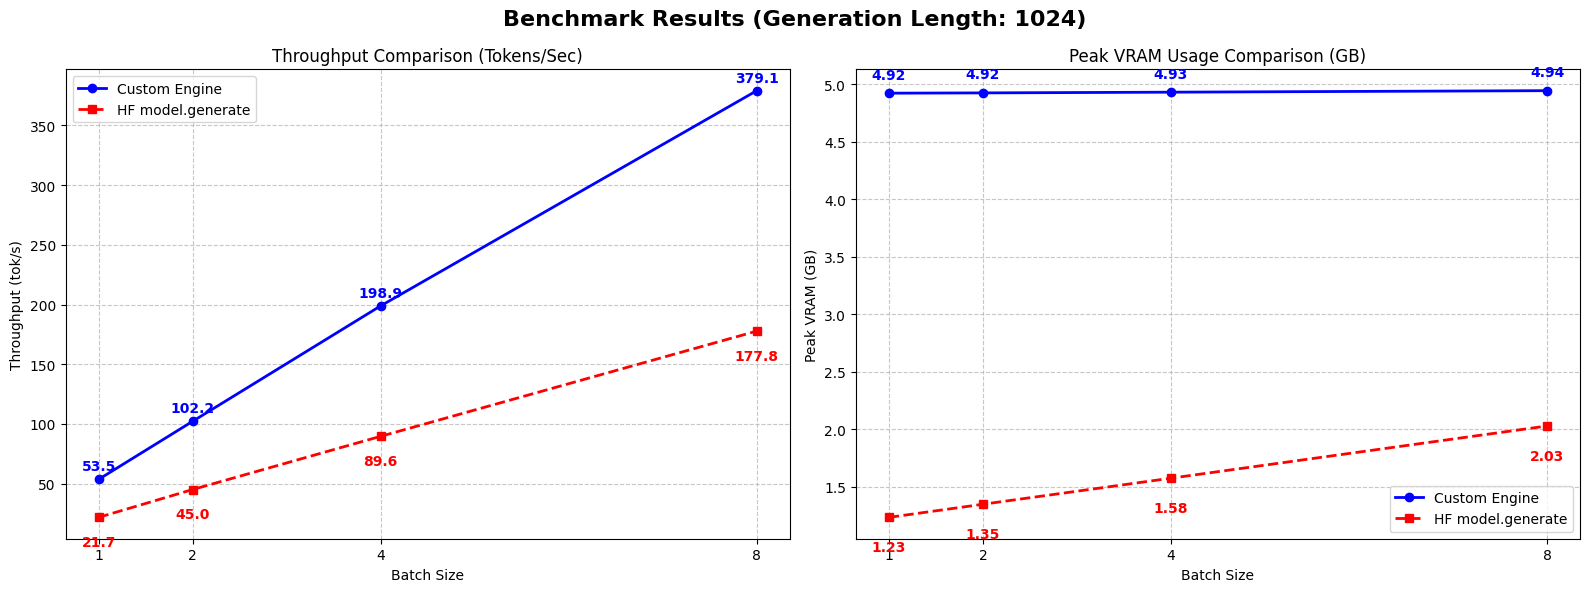

In [ ]:
import time
import gc
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"

def run_unified_benchmark(batch_sizes=[1, 2, 4, 8], max_new_tokens=1024, prompt_text="Generate a very long and detailed story about artificial intelligence."):
    custom_tps_results, hf_tps_results = [], []
    custom_mem_results, hf_mem_results = [], []

    hf_model_id = "Qwen/Qwen3-0.6B"
    hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_id)
    if hf_tokenizer.pad_token is None:
        hf_tokenizer.pad_token = hf_tokenizer.eos_token

    custom_prompt_ids = hf_tokenizer.encode(prompt_text)
    hf_input_ids = hf_tokenizer(prompt_text, return_tensors="pt").input_ids.to("cuda")

   
    print("\n=== Initializing Custom Engine ===")
    local_mgr = PagedKVManager(Qwen3Config, max_blocks=128, device="cuda")
    custom_model = get_qwen3_model()
    custom_model.to("cuda")
    bench_engine = ContinuousBatchEngine(custom_model, local_mgr, Qwen3Config)

    print("--- Custom Engine Warmup ---")
    bench_engine.reset()
    bench_engine.add_sequence(custom_prompt_ids, max_gen_len=150)
    while bench_engine.waiting_room or bench_engine.active:
        bench_engine.step()
    torch.cuda.synchronize()

    for bs in batch_sizes:
        print(f"\n[Custom Engine] Testing Batch Size: {bs}")
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
        bench_engine.reset()
        for _ in range(bs):
            bench_engine.add_sequence(custom_prompt_ids, max_gen_len=max_new_tokens)

        torch.cuda.synchronize()
        start_time = time.time()
        total_custom_tokens = 0

        while bench_engine.waiting_room or bench_engine.active:
            finished = bench_engine.step()
            for sid, tokens in finished.items():
                total_custom_tokens += len(tokens) - len(custom_prompt_ids)

        torch.cuda.synchronize()
        end_time = time.time()

        custom_peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
        custom_duration = end_time - start_time
        custom_tps = total_custom_tokens / custom_duration

        custom_tps_results.append(custom_tps)
        custom_mem_results.append(custom_peak_mem)
        print(f"[Custom Engine] TPS: {custom_tps:6.2f} tokens/s | Peak VRAM: {custom_peak_mem:.2f} GB")

    # Unload Custom Model to free VRAM for HF benchmark
    del bench_engine, custom_model, local_mgr
    gc.collect()
    torch.cuda.empty_cache()


    print("\n=== Loading Hugging Face Model ===")
    hf_model = AutoModelForCausalLM.from_pretrained(
        hf_model_id,
        torch_dtype=torch.bfloat16,
        device_map="cuda",
        attn_implementation="flash_attention_2"
    )

    print("--- HF Model Warmup ---")
    with torch.inference_mode():
        _ = hf_model.generate(hf_input_ids, max_new_tokens=150, do_sample=False)
    torch.cuda.synchronize()

    for bs in batch_sizes:
        print(f"\n[HF model.gen] Testing Batch Size: {bs}")
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        batch_input_ids = hf_input_ids.repeat(bs, 1)
        attention_mask = torch.ones_like(batch_input_ids)

        torch.cuda.synchronize()
        start_time = time.time()

        try:
            with torch.inference_mode():
                _ = hf_model.generate(
                    batch_input_ids,
                    attention_mask=attention_mask,
                    max_new_tokens=max_new_tokens,
                    min_new_tokens=max_new_tokens,
                    do_sample=False,
                    use_cache=True
                )
            torch.cuda.synchronize()
            end_time = time.time()

            hf_peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
            hf_duration = end_time - start_time
            total_hf_tokens = bs * max_new_tokens
            hf_tps = total_hf_tokens / hf_duration

            hf_tps_results.append(hf_tps)
            hf_mem_results.append(hf_peak_mem)
            print(f"[HF model.gen]  TPS: {hf_tps:6.2f} tokens/s | Peak VRAM: {hf_peak_mem:.2f} GB")

        except torch.cuda.OutOfMemoryError:
            print(f"[HF model.gen]  OOM encountered at Batch Size {bs}. Skipping higher batch sizes.")
            # Fill remaining batch sizes with None for clean plotting
            for _ in range(len(batch_sizes) - len(hf_tps_results)):
                hf_tps_results.append(None)
                hf_mem_results.append(None)
            break

    del hf_model
    gc.collect()
    torch.cuda.empty_cache()


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Filter out None values for HF in case of OOM
    valid_hf_bs = [bs for bs, val in zip(batch_sizes, hf_tps_results) if val is not None]
    valid_hf_tps = [val for val in hf_tps_results if val is not None]
    valid_hf_mem = [val for val in hf_mem_results if val is not None]

  
    ax1.plot(batch_sizes, custom_tps_results, marker='o', linestyle='-', color='b', linewidth=2, label='Custom Engine')
    ax1.plot(valid_hf_bs, valid_hf_tps, marker='s', linestyle='--', color='r', linewidth=2, label='HF model.generate')
    ax1.set_title('Throughput Comparison (Tokens/Sec)')
    ax1.set_xlabel('Batch Size')
    ax1.set_ylabel('Throughput (tok/s)')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xticks(batch_sizes)
    ax1.legend()

    for x, y_c in zip(batch_sizes, custom_tps_results):
        ax1.text(x, y_c + 5, f"{y_c:.1f}", ha='center', va='bottom', color='b', fontweight='bold')
    for x, y_h in zip(valid_hf_bs, valid_hf_tps):
        ax1.text(x, y_h - 15, f"{y_h:.1f}", ha='center', va='top', color='r', fontweight='bold')

    # --- Subplot 2: VRAM ---
    ax2.plot(batch_sizes, custom_mem_results, marker='o', linestyle='-', color='b', linewidth=2, label='Custom Engine')
    ax2.plot(valid_hf_bs, valid_hf_mem, marker='s', linestyle='--', color='r', linewidth=2, label='HF model.generate')
    ax2.set_title('Peak VRAM Usage Comparison (GB)')
    ax2.set_xlabel('Batch Size')
    ax2.set_ylabel('Peak VRAM (GB)')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_xticks(batch_sizes)
    ax2.legend()

    for x, y_c in zip(batch_sizes, custom_mem_results):
        ax2.text(x, y_c + 0.1, f"{y_c:.2f}", ha='center', va='bottom', color='b', fontweight='bold')
    for x, y_h in zip(valid_hf_bs, valid_hf_mem):
        ax2.text(x, y_h - 0.2, f"{y_h:.2f}", ha='center', va='top', color='r', fontweight='bold')

    plt.suptitle(f"Benchmark Results (Generation Length: {max_new_tokens})", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run refactored benchmark
run_unified_benchmark(batch_sizes=[1, 2, 4, 8], max_new_tokens=1024)

In [8]:
# Load model and tokenizer
tokenizer = get_qwen3_tokenizer()
model = get_qwen3_model()

print("✓ Model and Tokenizer initialized on device successfully!")

✓ Model and Tokenizer initialized on device successfully!


In [9]:
import torch
torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

In [10]:
from simplevllm.models import Qwen3Config
mgr = PagedKVManager(Qwen3Config, max_blocks=32, device=device)

In [11]:
prompt = "Give me a short introduction to large language models."

input_token_ids1 = tokenizer.encode(prompt)

In [12]:
prompt = "Give me a short introduction to AI"

input_token_ids3 = tokenizer.encode(prompt)

In [13]:
prompt = "Give me a short introduction to Embeddings in nlp"

input_token_ids2 = tokenizer.encode(prompt)

In [14]:
batched_engine = ContinuousBatchEngine(model, mgr, Qwen3Config)
print("BatchedEngine ready")

BatchedEngine ready


In [15]:
my_prompts = [
    input_token_ids1,
    input_token_ids2,
    input_token_ids3
]
batched_engine.reset()
for prompt in my_prompts:
    batched_engine.add_sequence(prompt,max_gen_len = 512)


while batched_engine.waiting_room or batched_engine.active:
    finished = batched_engine.step()
     # Print results as they come in
    for sid, tokens in finished.items():
        print(f"Slot {sid} finished. Total length: {len(tokens)}")
        print(tokenizer.decode(tokens))
        print("-" * 30)

Slot 2 finished. Total length: 176
<|im_start|>user
Give me a short introduction to AI<|im_end|>
<|im_start|>assistant
<think>
Okay, the user wants a short introduction to AI. Let me start by defining what AI is. I should mention it's a technology that helps machines think and learn. Maybe include some key points like machine learning, natural language processing, and applications. Need to keep it concise but informative. Also, make sure to highlight the benefits and the current state of AI. Avoid technical jargon to keep it accessible. Let me check if I'm covering all important aspects without being too detailed. Yeah, that should work.
</think>

AI, or artificial intelligence, is a technology that enables machines to think and learn from data. It uses algorithms and machine learning to analyze information and make decisions. AI has applications in various fields, from healthcare to finance, and is becoming increasingly important in everyday life.<|im_end|>
---------------------------

In [16]:
! pip install gradio

In [17]:
import os
import threading
import uuid

import gradio as gr
import torch


class GradioRuntime:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = tokenizer
        self.model = model

        max_blocks = int(os.getenv("SIMPLEVLLM_MAX_BLOCKS", "256"))
        self.kv_manager = PagedKVManager(
            Qwen3Config,
            max_blocks=max_blocks,
            device=self.device,
        )
        self.engine = ContinuousBatchEngine(
            self.model,
            self.kv_manager,
            Qwen3Config,
        )
        self.conversations: dict[str, list[dict[str, str]]] = {}
        self.lock = threading.Lock()

    def _encode_history(self, history: list[dict[str, str]]) -> list[int]:
        prompt_ids: list[int] = []
        for item in history:
            turn = f"<|im_start|>{item['role']}\n{item['content']}<|im_end|>\n"
            prompt_ids.extend(self.tokenizer.encode(turn, chat_wrapped=False))

        prompt_ids.extend(
            self.tokenizer.encode("<|im_start|>assistant\n", chat_wrapped=False)
        )
        return prompt_ids

    def stream(self, conversation_id: str | None, message: str, max_new_tokens: int):
        conversation_id = conversation_id or uuid.uuid4().hex
        history = list(self.conversations.get(conversation_id, []))
        history.append({"role": "user", "content": message})
        prompt_ids = self._encode_history(history)

        if len(prompt_ids) + max_new_tokens > Qwen3Config["context_length"]:
            raise ValueError("Conversation is too long for the model context window")

        with self.lock:
            self.engine.reset()
            self.engine.add_sequence(prompt_ids, max_gen_len=max_new_tokens)
            generated_ids: list[int] | None = None
            answer = ""

            while self.engine.waiting_room or self.engine.active:
                for event in self.engine.step_single():
                    answer += self.tokenizer.decode([event["token_id"]])
                    answer = answer.split("<|im_end|>", 1)[0]
                    yield conversation_id, answer
                    if event["finished"]:
                        generated_ids = event["tokens"][len(prompt_ids):]

        if generated_ids is None:
            raise RuntimeError("The engine did not produce a response")

        final_answer = self.tokenizer.decode(generated_ids)
        final_answer = final_answer.split("<|im_end|>", 1)[0].strip()
        if not final_answer:
            final_answer = answer.strip()

        history.append({"role": "assistant", "content": final_answer})
        self.conversations[conversation_id] = history
        if final_answer != answer:
            yield conversation_id, final_answer


def create_demo(runtime: GradioRuntime | None = None) -> gr.Blocks:
    runtime = runtime or GradioRuntime()

    def respond(message, history, conversation_id, max_new_tokens):
        if not message or not message.strip():
            yield "", history, conversation_id
            return

        display_history = list(history or [])
        display_history.extend(
            [
                {"role": "user", "content": message},
                {"role": "assistant", "content": ""},
            ]
        )
        try:
            for conversation_id, answer in runtime.stream(
                conversation_id, message.strip(), int(max_new_tokens)
            ):
                display_history = [
                    *display_history[:-1],
                    {**display_history[-1], "content": answer},
                ]
                yield "", display_history, conversation_id
        except Exception as error:
            display_history = [
                *display_history[:-1],
                {**display_history[-1], "content": f"Error: {error}"},
            ]
            yield "", display_history, conversation_id

    def clear_chat():
        return [], None

    with gr.Blocks(title="SimpleVLLM Chat") as demo:
        gr.Markdown("# SimpleVLLM Chat")
        chatbot = gr.Chatbot(type="messages", height=600)
        conversation_id = gr.State(value=None)
        with gr.Row():
            message = gr.Textbox(
                placeholder="Message SimpleVLLM...",
                show_label=False,
                scale=8,
            )
            send = gr.Button("Send", variant="primary", scale=1)
        with gr.Row():
            max_new_tokens = gr.Slider(
                minimum=1,
                maximum=1024,
                value=256,
                step=1,
                label="Max new tokens",
            )
            clear = gr.Button("New chat")

        inputs = [message, chatbot, conversation_id, max_new_tokens]
        outputs = [message, chatbot, conversation_id]
        send.click(respond, inputs=inputs, outputs=outputs)
        message.submit(respond, inputs=inputs, outputs=outputs)
        clear.click(clear_chat, outputs=[chatbot, conversation_id])

    return demo


def main() -> None:
    create_demo().queue().launch()


# if __name__ == "__main__":
#     main()